## **Confidence Intervals**
This part estimates the average stock return with a certain confidence level.

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from google.colab import files
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
#upload required stock data
#data = files.upload()
ms = pd.read_csv('microsoft.csv', index_col= 'Date')
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


### **Estimating the average stock return with 90% Confidence Interval**

In [43]:
# i will use log return for average stock return of Microsoft
ms['logReturn'] = np.log(ms['Close'].shift(-1)) - np.log(ms['Close'])

In [44]:
# compute sample statistics
log_returns = ms['logReturn'].dropna()  # ensuring no NaNs
n = log_returns.shape[0]
sample_mean = log_returns.mean()
std_error = log_returns.std(ddof=1) / np.sqrt(n)

# define 90% confidence level and corresponding Z-score
confidence_level = 0.90
z_score = norm.ppf(1 - (1 - confidence_level) / 2)  # ~1.645 for 90% CI

# compute confidence interval bounds
ci_lower = sample_mean - z_score * std_error
ci_upper = sample_mean + z_score * std_error

# output the result
print(f"90% Confidence Interval for Log Returns: ({ci_lower:.6f}, {ci_upper:.6f})")

90% Confidence Interval for Log Returns: (-0.000016, 0.001657)


>90% confidence interval tells you that there will be 90% chance that the average stock return lies between "ci_lower" and "ci_upper".

## **Hypothesis Testing**

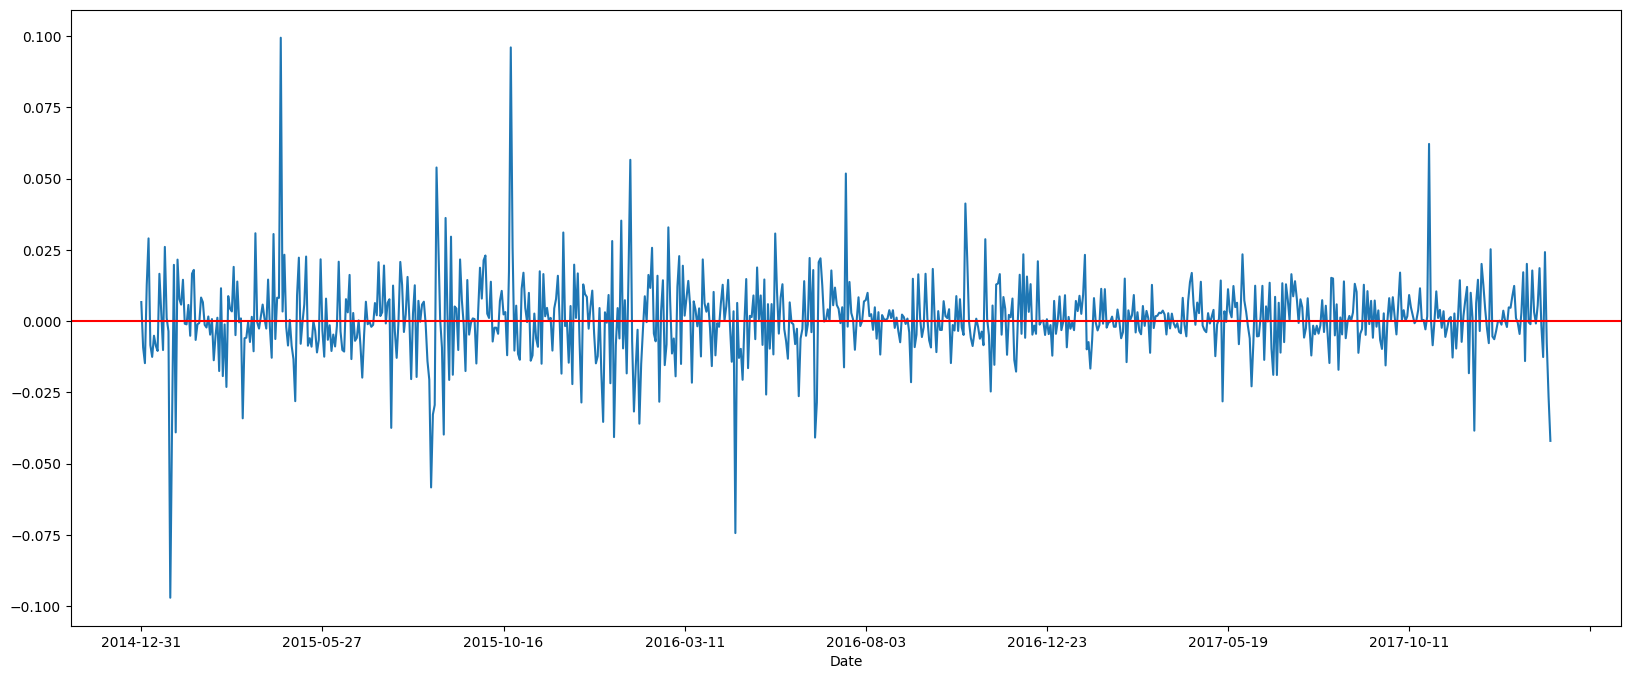

In [45]:
# Log return goes up and down during the period
ms['logReturn'].plot(figsize=(20, 8))
plt.axhline(0, color='red')
plt.show()

### **Steps involved in testing a claim by hypothesis testing**

### **Step 1: Set Hypothesis**

\begin{aligned}
H_0\!:~\mu &= 0 \; \text{(null hypothesis: the average stock return is zero)} \\
H_a\!:~\mu &\neq 0 \; \text{(alternative hypothesis: the average stock return is not zero)}
\end{aligned}

### **Step 2: Calculating Test Statistic**

In [53]:
# null hypothesis: μ = 0
mu_0 = 0

# compute z-test statistic (assuming large sample size)
# if sample size n is large enough, we can use z-distribution, instead of t-distribtuion
z_statistic = (sample_mean - mu_0) / std_error

# result
print(f"z-test statistic: {z_statistic:.4f}")

z-test statistic: 1.6131


### **Step 3: Set Decision Criteria**

In [54]:
# set significance level
alpha = 0.05
confidence_level = 1 - alpha

# compute critical z-values for two-tailed test
z_left = norm.ppf(alpha / 2)
z_right = -z_left  # symmetry of standard normal distribution

# output results
print(f"Critical z-values for a {confidence_level:.0%} confidence level: "
      f"({z_left:.4f}, {z_right:.4f})")

Critical z-values for a 95% confidence level: (-1.9600, 1.9600)


### **Step 4: Decision Making - shall we reject $H_0$**

In [55]:
print('at significant level of {}, shall we reject: {}'.format(alpha, z_statistic>z_right or z_statistic<z_left))

at significant level of 0.05, shall we reject: False


### **P-Value**

> you can also use the p-value method to make a decision





In [63]:
# compute p-value (two-tailed test)
p_value = (1 - norm.cdf(abs(z_statistic)))  # use abs for two tails

# decision rule
reject_null = p_value < alpha

# results
print(f"p-value: {p_value:.4f}")
print(f"at significance level α = {alpha}, reject H₀: {reject_null}")

p-value: 0.0534
at significance level α = 0.05, reject H₀: False
